# The Experts Hackathon 2026
## Задание 1. Проверка качества данных

**Цель:** перед анализом A/B-теста убедиться, что исходные данные достаточно качественные и понять, какие проблемы необходимо учесть при дальнейших расчётах.

В рамках аудита проверяем:

1. пропуски;
2. полные дубли и дубли ключей;
3. аномальных пользователей;
4. технически продублированные события;
5. корректность распределения пользователей между `control` и `test`;
6. баланс основных характеристик пользователей;
7. целостность связей между таблицами;
8. временные особенности возвратов;
9. формируем правила очистки данных для дальнейшего анализа.


### 1. Загрузка библиотек и данных

Ноутбук ищет CSV сначала в папке `data/`, а если её нет — рядом с самим notebook.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chisquare, chi2_contingency

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

DATA_DIR = Path("data") if Path("data/users.csv").exists() else Path(".")

names = [
    "users",
    "experiment_assignments",
    "sessions",
    "impressions",
    "clicks",
    "orders",
    "products",
    "sellers",
    "premium_subscriptions",
    "support_tickets",
]

tables = {name: pd.read_csv(DATA_DIR / f"{name}.csv") for name in names}

users = tables["users"]
exp = tables["experiment_assignments"]
sessions = tables["sessions"]
impressions = tables["impressions"]
clicks = tables["clicks"]
orders = tables["orders"]
products = tables["products"]
sellers = tables["sellers"]
premium = tables["premium_subscriptions"]
tickets = tables["support_tickets"]

print("Все таблицы успешно загружены.")


Все таблицы успешно загружены.


### 2. Первичный обзор датасета

Сначала посмотрим размер каждой таблицы: количество строк и столбцов.


In [2]:
overview = pd.DataFrame({
    "table": list(tables.keys()),
    "rows": [len(df) for df in tables.values()],
    "columns": [df.shape[1] for df in tables.values()]
})

overview


,table,rows,columns
0,users,50000,8
1,experiment_assignments,50300,6
2,sessions,164739,9
3,impressions,1066434,9
4,clicks,91266,7
5,orders,7407,14
6,products,4500,8
7,sellers,700,5
8,premium_subscriptions,9127,6
9,support_tickets,337,7


### 3. Проверка пропусков

Пустое значение не всегда означает ошибку. Например, `return_date` логично отсутствует у заказа, который не был возвращён.

Поэтому сначала найдём все пропуски, а затем отдельно проверим их смысл.


In [3]:
missing_rows = []

for name, df in tables.items():
    for column, count in df.isna().sum().items():
        if count > 0:
            missing_rows.append({
                "table": name,
                "column": column,
                "missing_count": int(count),
                "missing_share_pct": round(count / len(df) * 100, 2)
            })

missing_report = pd.DataFrame(missing_rows)

if missing_report.empty:
    print("Пропусков не обнаружено.")
else:
    display(missing_report)


,table,column,missing_count,missing_share_pct
0,orders,delivery_fee_rub,303,4.0900
1,orders,return_date,6945,93.7600


#### Проверка `return_date`

Если данные корректны, то:
- для `is_returned = 1` дата возврата должна быть заполнена;
- для `is_returned = 0` дата возврата должна отсутствовать.


In [4]:
print("Всего заказов:", len(orders))
print("Возвратов:", int(orders["is_returned"].sum()))
print("Заполненных return_date:", int(orders["return_date"].notna().sum()))

print(
    "Возврат есть, а даты нет:",
    int(((orders["is_returned"] == 1) & orders["return_date"].isna()).sum())
)

print(
    "Возврата нет, а дата есть:",
    int(((orders["is_returned"] == 0) & orders["return_date"].notna()).sum())
)


Всего заказов: 7407
Возвратов: 462
Заполненных return_date: 462
Возврат есть, а даты нет: 0
Возврата нет, а дата есть: 0


**Вывод:** пропуски в `return_date` являются ожидаемыми и не считаются проблемой качества данных.

В `delivery_fee_rub` отсутствует часть значений. Автоматически заменять их на `0` нельзя: нулевая стоимость доставки может быть реальным значением, поэтому такая замена смешала бы «бесплатную доставку» и «неизвестное значение».


### 4. Проверка полных дублей и уникальности ключей


In [5]:
duplicate_report = pd.DataFrame({
    "table": list(tables.keys()),
    "full_row_duplicates": [int(df.duplicated().sum()) for df in tables.values()]
})

duplicate_report


,table,full_row_duplicates
0,users,0
1,experiment_assignments,0
2,sessions,0
3,impressions,0
4,clicks,0
5,orders,0
6,products,0
7,sellers,0
8,premium_subscriptions,0
9,support_tickets,0


In [6]:
primary_keys = {
    "users": "user_id",
    "experiment_assignments": "assignment_id",
    "sessions": "session_id",
    "impressions": "impression_id",
    "clicks": "click_id",
    "orders": "order_id",
    "products": "product_id",
    "sellers": "seller_id",
    "support_tickets": "ticket_id",
}

key_report = []

for table_name, key in primary_keys.items():
    key_report.append({
        "table": table_name,
        "key": key,
        "duplicated_key_values": int(tables[table_name][key].duplicated().sum())
    })

pd.DataFrame(key_report)


,table,key,duplicated_key_values
0,users,user_id,0
1,experiment_assignments,assignment_id,0
2,sessions,session_id,0
3,impressions,impression_id,0
4,clicks,click_id,0
5,orders,order_id,0
6,products,product_id,0
7,sellers,seller_id,0
8,support_tickets,ticket_id,0


**Вывод:** полных одинаковых строк и дублей основных идентификаторов не обнаружено.

Но это ещё не означает, что экспериментальные назначения корректны: один и тот же `user_id` может иметь разные `assignment_id`. Это проверяем отдельно.


### 5. Пользователи, попавшие одновременно в control и test


In [7]:
groups_per_user = exp.groupby("user_id")["experiment_group"].nunique()
cross_assigned_users = groups_per_user[groups_per_user > 1].index

print("Строк в experiment_assignments:", len(exp))
print("Уникальных пользователей:", exp["user_id"].nunique())
print("Пользователей сразу в двух группах:", len(cross_assigned_users))
print("Доля от всех пользователей:",
      f"{len(cross_assigned_users) / users['user_id'].nunique() * 100:.2f}%")

print("\nИсточник назначений:")
display(exp["assignment_source"].value_counts().to_frame("rows"))


Строк в experiment_assignments: 50300
Уникальных пользователей: 50000
Пользователей сразу в двух группах: 300
Доля от всех пользователей: 0.60%

Источник назначений:


,rows
assignment_source,
assignment_service,50000
assignment_service_bug,300


**Вывод:** обнаружено **300 пользователей (~0.6%)**, которые получили назначения и в `control`, и в `test`.

Дополнительные строки имеют источник `assignment_service_bug`, то есть это реальное загрязнение экспериментальных групп. Такие пользователи могут видеть разные варианты системы в разных сессиях, поэтому для основного «чистого» анализа их разумно исключить. Позже можно использовать их в sensitivity analysis как проверку устойчивости вывода.


### 6. Аномальные пользователи / bot candidates

В `users` есть специальный признак `is_bot_candidate`. Проверим, действительно ли отмеченные пользователи отличаются по активности.


In [8]:
print(users["is_bot_candidate"].value_counts().rename(index={0: "обычные", 1: "bot candidate"}))
print()
print("Доля bot candidates:",
      f"{users['is_bot_candidate'].mean() * 100:.2f}%")


is_bot_candidate
обычные          49600
bot candidate      400
Name: count, dtype: int64

Доля bot candidates: 0.80%


In [9]:
user_activity = (
    sessions
    .groupby("user_id")
    .agg(
        sessions_count=("session_id", "count"),
        total_page_views=("page_views", "sum"),
        avg_session_duration_sec=("session_duration_sec", "mean")
    )
    .reset_index()
    .merge(users[["user_id", "is_bot_candidate"]], on="user_id", how="left")
)

bot_activity = (
    user_activity
    .groupby("is_bot_candidate")[
        ["sessions_count", "total_page_views", "avg_session_duration_sec"]
    ]
    .mean()
)

bot_activity.index = ["обычные пользователи", "bot candidates"]
bot_activity


,sessions_count,total_page_views,avg_session_duration_sec
обычные пользователи,3.1916,22.3268,272.9089
bot candidates,16.0900,578.3225,820.9960


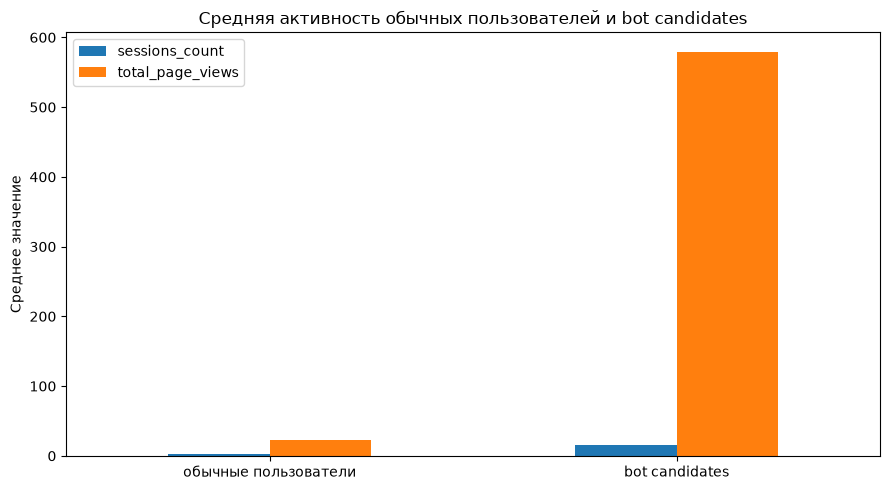

In [10]:
plot_data = bot_activity[["sessions_count", "total_page_views"]].copy()

ax = plot_data.plot(kind="bar", figsize=(9, 5))
ax.set_title("Средняя активность обычных пользователей и bot candidates")
ax.set_ylabel("Среднее значение")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Вывод:** bot candidates имеют кратно более высокую активность. Они способны непропорционально влиять на CTR, число показов, просмотров и другие поведенческие метрики.

Для основного анализа исключаем этих пользователей, но в финальной работе желательно дополнительно сравнить результаты с анализом без такого исключения.


### 7. Технически продублированные показы


In [11]:
duplicate_impressions = int(impressions["is_duplicate_event"].sum())
duplicate_impressions_share = impressions["is_duplicate_event"].mean() * 100

print("Всего показов:", len(impressions))
print("Помечено как duplicate event:", duplicate_impressions)
print("Доля:", f"{duplicate_impressions_share:.3f}%")


Всего показов: 1066434
Помечено как duplicate event: 3193
Доля: 0.299%


**Вывод:** технически продублированные показы могут искусственно увеличивать знаменатель CTR. В основном анализе такие события следует исключить.


### 8. Корректность распределения control / test

В качестве исходного назначения используем строки `assignment_source == "assignment_service"`: их ровно по одной на каждого пользователя. Баговые дополнительные назначения анализируем отдельно как contamination.


In [12]:
canonical_assignment = exp[
    exp["assignment_source"] == "assignment_service"
].copy()

print("Строк:", len(canonical_assignment))
print("Уникальных пользователей:", canonical_assignment["user_id"].nunique())

group_counts = canonical_assignment["experiment_group"].value_counts()
group_counts


Строк: 50000
Уникальных пользователей: 50000


experiment_group
test       25185
control    24815
Name: count, dtype: int64

In [13]:
observed = group_counts.reindex(["control", "test"]).values

srm_test = chisquare(
    observed,
    f_exp=[len(canonical_assignment) / 2, len(canonical_assignment) / 2]
)

print("Chi-square statistic:", round(float(srm_test.statistic), 4))
print("p-value:", round(float(srm_test.pvalue), 4))

if srm_test.pvalue > 0.05:
    print("Вывод: статистически значимого отклонения от распределения 50/50 не обнаружено.")
else:
    print("Вывод: есть признаки Sample Ratio Mismatch (SRM).")


Chi-square statistic: 2.738
p-value: 0.098
Вывод: статистически значимого отклонения от распределения 50/50 не обнаружено.


Здесь `p-value > 0.05`, поэтому по численности групп нет оснований считать, что механизм рандомизации дал существенный перекос.


### 9. Баланс характеристик пользователей

Даже если группы близки по размеру, важно проверить, похожи ли они по основным наблюдаемым характеристикам.


In [14]:
balance_data = users.merge(
    canonical_assignment[["user_id", "experiment_group"]],
    on="user_id",
    how="inner"
)

balance_columns = [
    "device",
    "region",
    "age_group",
    "traffic_source",
    "is_premium",
    "is_bot_candidate",
]

balance_results = []

for column in balance_columns:
    contingency = pd.crosstab(
        balance_data[column],
        balance_data["experiment_group"]
    )

    chi2, p_value, dof, expected = chi2_contingency(contingency)

    balance_results.append({
        "feature": column,
        "p_value": p_value,
        "significant_difference_at_5pct": p_value < 0.05
    })

balance_results = pd.DataFrame(balance_results)
balance_results


,feature,p_value,significant_difference_at_5pct
0,device,0.1117,False
1,region,0.5072,False
2,age_group,0.6530,False
3,traffic_source,0.2039,False
4,is_premium,0.2382,False
5,is_bot_candidate,0.7648,False


In [15]:
pd.crosstab(
    balance_data["device"],
    balance_data["experiment_group"],
    normalize="columns"
).mul(100).round(2)


experiment_group,control,test
device,,
android,57.3300,58.2400
ios,27.3000,26.6000
web,15.3700,15.1600


**Вывод:** по проверенным наблюдаемым характеристикам статистически значимого дисбаланса между `control` и `test` не обнаружено. Это поддерживает предположение о корректной исходной рандомизации.


### 10. Проверка связей между таблицами

Проверяем базовую бизнес-логику:

`impression → click → order`

- клик должен ссылаться на существующий показ;
- заказ должен ссылаться на существующий клик;
- идентификаторы пользователя, сессии и товара должны быть согласованы.


In [16]:
integrity = {
    "clicks_without_impression":
        int((~clicks["impression_id"].isin(impressions["impression_id"])).sum()),

    "orders_without_click":
        int((~orders["click_id"].isin(clicks["click_id"])).sum()),

    "impressions_without_user":
        int((~impressions["user_id"].isin(users["user_id"])).sum()),

    "sessions_without_user":
        int((~sessions["user_id"].isin(users["user_id"])).sum()),

    "orders_without_user":
        int((~orders["user_id"].isin(users["user_id"])).sum()),
}

pd.Series(integrity, name="broken_links").to_frame()


,broken_links
clicks_without_impression,0
orders_without_click,0
impressions_without_user,0
sessions_without_user,0
orders_without_user,0


In [17]:
click_imp = clicks.merge(
    impressions[
        ["impression_id", "user_id", "session_id", "product_id", "is_clicked"]
    ],
    on="impression_id",
    how="left",
    suffixes=("_click", "_imp")
)

order_click = orders.merge(
    clicks[["click_id", "user_id", "session_id", "product_id"]],
    on="click_id",
    how="left",
    suffixes=("_order", "_click")
)

consistency = {
    "click_vs_impression_user_mismatch":
        int((click_imp["user_id_click"] != click_imp["user_id_imp"]).sum()),

    "click_vs_impression_session_mismatch":
        int((click_imp["session_id_click"] != click_imp["session_id_imp"]).sum()),

    "click_vs_impression_product_mismatch":
        int((click_imp["product_id_click"] != click_imp["product_id_imp"]).sum()),

    "click_from_impression_not_marked_clicked":
        int((click_imp["is_clicked"] != 1).sum()),

    "order_vs_click_user_mismatch":
        int((order_click["user_id_order"] != order_click["user_id_click"]).sum()),

    "order_vs_click_session_mismatch":
        int((order_click["session_id_order"] != order_click["session_id_click"]).sum()),

    "order_vs_click_product_mismatch":
        int((order_click["product_id_order"] != order_click["product_id_click"]).sum()),
}

pd.Series(consistency, name="mismatches").to_frame()


,mismatches
click_vs_impression_user_mismatch,0
click_vs_impression_session_mismatch,0
click_vs_impression_product_mismatch,0
click_from_impression_not_marked_clicked,0
order_vs_click_user_mismatch,0
order_vs_click_session_mismatch,0
order_vs_click_product_mismatch,0


**Вывод:** нарушений основных ссылочных связей и несогласованности `user_id / session_id / product_id` в цепочке `показ → клик → заказ` не обнаружено.


### 11. Временное окно и возвраты

Эксперимент наблюдался 30 дней, однако возврат товара может произойти позже даты покупки. Проверим диапазон дат.


In [18]:
orders_dates = orders.copy()
orders_dates["order_date"] = pd.to_datetime(orders_dates["order_date"])
orders_dates["return_date"] = pd.to_datetime(orders_dates["return_date"])

experiment_end = orders_dates["order_date"].max()

print("Первая дата заказа:", orders_dates["order_date"].min().date())
print("Последняя дата заказа:", experiment_end.date())
print("Последняя дата возврата:", orders_dates["return_date"].max().date())

late_returns = (
    orders_dates["return_date"].notna()
    & (orders_dates["return_date"] > experiment_end)
)

print("Возвратов после последнего дня заказов:", int(late_returns.sum()))


Первая дата заказа: 2026-07-01
Последняя дата заказа: 2026-07-30
Последняя дата возврата: 2026-09-04
Возвратов после последнего дня заказов: 300


**Вывод:** часть возвратов происходит уже после 30-дневного окна заказов. Это не ошибка данных, а важное ограничение интерпретации `Return Rate`: поздние покупки имеют меньше времени, чтобы успеть вернуться.


### 12. Формирование чистой когорты для дальнейшего анализа

Для основного анализа:

- исключаем 300 пользователей с конфликтующим назначением в обе группы;
- исключаем bot candidates;
- дублированные показы удаляем на уровне `impressions`;
- строки с пропущенным `delivery_fee_rub` не удаляем автоматически;
- `return_date` не заполняем для невозвращённых заказов.

Важно: это **основной clean/per-protocol вариант**. В финальном A/B-анализе желательно провести sensitivity check на менее очищенной выборке, чтобы показать, что вывод не является следствием одного конкретного правила фильтрации.


In [19]:
cross_assigned_set = set(cross_assigned_users)
bot_users_set = set(users.loc[users["is_bot_candidate"] == 1, "user_id"])

excluded_users = cross_assigned_set | bot_users_set
clean_user_ids = set(users["user_id"]) - excluded_users

clean_users = users[users["user_id"].isin(clean_user_ids)].copy()
clean_assignments = canonical_assignment[
    canonical_assignment["user_id"].isin(clean_user_ids)
].copy()

clean_sessions = sessions[sessions["user_id"].isin(clean_user_ids)].copy()

clean_impressions = impressions[
    impressions["user_id"].isin(clean_user_ids)
    & (impressions["is_duplicate_event"] == 0)
].copy()

clean_clicks = clicks[clicks["user_id"].isin(clean_user_ids)].copy()
clean_orders = orders[orders["user_id"].isin(clean_user_ids)].copy()
clean_premium = premium[premium["user_id"].isin(clean_user_ids)].copy()
clean_tickets = tickets[tickets["user_id"].isin(clean_user_ids)].copy()

print("Исключено уникальных пользователей:", len(excluded_users))
print("Осталось пользователей:", len(clean_users))
print()
print("Распределение чистой когорты:")
display(clean_assignments["experiment_group"].value_counts().to_frame("users"))

print("Показы до очистки:", len(impressions))
print("Показы после очистки:", len(clean_impressions))


Исключено уникальных пользователей: 699
Осталось пользователей: 49301

Распределение чистой когорты:


,users
experiment_group,
test,24828
control,24473


Показы до очистки: 1066434
Показы после очистки: 1015160


## Итоговый вывод по заданию 1

Первичный аудит показал, что датасет в целом имеет хорошую ссылочную целостность, но содержит несколько заранее значимых для A/B-теста проблем.

**Обнаружено:**

- полных дублей строк и дублей основных первичных ключей нет;
- 300 пользователей (~0.6%) получили назначения одновременно в `control` и `test`; дополнительные назначения связаны с `assignment_service_bug`;
- 400 пользователей (0.8%) отмечены как `bot candidates` и демонстрируют аномально высокую активность;
- 3193 показа (~0.3%) отмечены как технически дублированные события;
- в `orders.delivery_fee_rub` отсутствует 303 значения (~4.1%);
- пропуски `return_date` логичны и полностью согласованы с признаком `is_returned`;
- исходное распределение пользователей близко к 50/50: 24 815 `control` и 25 185 `test`;
- статистически значимого Sample Ratio Mismatch не обнаружено;
- по device, region, age group, traffic source, Premium status и bot flag заметного дисбаланса между исходными группами не обнаружено;
- нарушений связей `impression → click → order` не найдено;
- часть возвратов происходит после конца 30-дневного окна, поэтому метрика возвратов подвержена правому цензурированию.

**Принятый подход для основного анализа:**

1. исключить пользователей с конфликтующим назначением в обе группы;
2. исключить bot candidates;
3. удалить `is_duplicate_event = 1` из показов;
4. не интерпретировать пустой `return_date` как ошибку;
5. не заменять пропущенный `delivery_fee_rub` на ноль без дополнительного обоснования;
6. использовать очищенную когорту как основной вариант и в дальнейшем провести sensitivity analysis на альтернативных правилах очистки.

После исключения конфликтующих назначений и bot candidates остаётся **49 301 пользователь**: **24 473 control** и **24 828 test**.

Таким образом, после описанной очистки данные пригодны для дальнейшего EDA, анализа воронки и оценки результатов A/B-теста.
